<a href="https://colab.research.google.com/github/sba25046/ml-test/blob/main/Mall_Customers_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mall Customers Dataset


This is an unsupervised learning problem as there are no labels, the goal is for the algorithm to find hidden patterns or groupings.

method chosen: k-means clustering

objective: Find natural segments in
mall customers based on their annual income and spending score





# Import libraries

In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Import the CSV data

Note for Sam: I used the 'Files' section of colab to first upload the dataset to Colab. If you are testing this code please upload the file and ensure it matches the name Ive used in the code.

In [23]:
df = pd.read_csv("MallCustomers.csv")

# Explore the dataset

In [24]:
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre
0,1,19,15,39,Male
1,2,21,15,81,Male
2,3,20,16,6,Female
3,4,23,16,77,Female
4,5,31,17,40,Female


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
 4   Genre                   200 non-null    object
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [26]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Genre,0


there are no missing values or duplicates. The dataset looks clean.



# K-Means Model

I chose to focus on Annual Income and Spending Score as these are the most business-relevant features for customer segmentation as they directly reflect purchasing behaviour. Adding Age or Genre to K-Means without a clear reason could hurt the clustering quality, since the algorithm treats all features equally and has no way to tell which ones matter the most.

In [29]:

#select the features for clustering

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [30]:
# Scale the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
# Start with 3 clusters as a first guess
kMeans = KMeans(n_clusters=3)
y = kMeans.fit_predict(X_scaled)
print(y)

[2 2 1 2 2 2 1 2 1 2 1 2 1 2 1 2 2 2 2 2 2 2 1 2 1 2 2 2 2 2 1 2 1 2 1 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]


In [32]:
#see how data is getting clustereddf["cluster"] = y
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre
0,1,19,15,39,Male
1,2,21,15,81,Male
2,3,20,16,6,Female
3,4,23,16,77,Female
4,5,31,17,40,Female


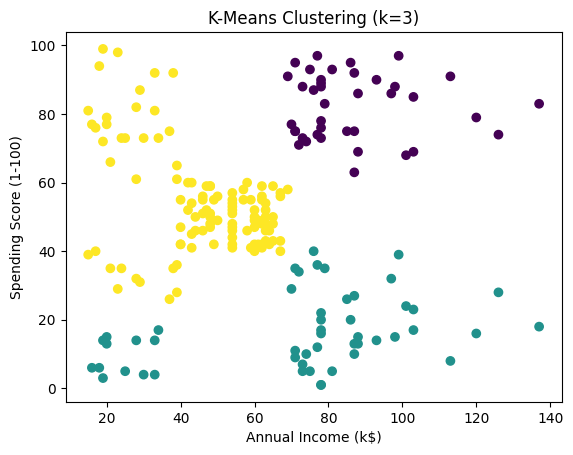

In [33]:
df["cluster"] = y
# visualise the clusters with a scatter plot
plt.scatter(
    x = df["Annual Income (k$)"],
    y = df["Spending Score (1-100)"],
    c = df["cluster"]
);
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering (k=3)")
plt.show()